# Evaluation and Error Analysis

This notebook evaluates a baseline RandomForest model with a preprocessing pipeline, visualizes the
confusion matrix, inspects errors, and summarizes feature importance.


## 0. Setup

Import libraries and define file paths.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)

plt.style.use("seaborn-v0_8-whitegrid")

DATA_PATH = Path("../data/processed/diabetes_clean.csv")
TARGET_COL = "CLASS"
ID_COL_CANDIDATES = ["ID", "No_Pation"]
RANDOM_STATE = 42


## 1. Load Cleaned Data and Split


In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Missing data file: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()

if "Gender" in df.columns:
    df["Gender"] = df["Gender"].astype(str).str.strip().str.upper()

id_cols = [c for c in ID_COL_CANDIDATES if c in df.columns]
df = df.drop(columns=id_cols, errors="ignore")

if TARGET_COL not in df.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found.")

y = df[TARGET_COL].astype(str).str.strip()
X = df.drop(columns=[TARGET_COL])

# Strict check: fail fast on missing/invalid values
if df.isna().any().any():
    missing_cols = df.columns[df.isna().any()].tolist()
    raise ValueError(f"Missing values detected in columns: {missing_cols}")

obj_cols = df.select_dtypes(include="object").columns
if len(obj_cols) > 0:
    empty_mask = df[obj_cols].astype(str).apply(lambda s: s.str.strip().eq(""))
    if empty_mask.any().any():
        empty_cols = empty_mask.columns[empty_mask.any()].tolist()
        raise ValueError(f"Empty string values detected in columns: {empty_cols}")

num_cols_all = df.select_dtypes(include="number").columns
if len(num_cols_all) > 0:
    inf_mask = df[num_cols_all].isin([np.inf, -np.inf])
    if inf_mask.any().any():
        inf_cols = inf_mask.columns[inf_mask.any()].tolist()
        raise ValueError(f"Infinity values detected in columns: {inf_cols}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

num_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols = X_train.select_dtypes(exclude="number").columns.tolist()

numeric_pipe = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
    ]
)
categorical_pipe = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop",
)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")


X_train: (800, 11) | X_test: (200, 11)
y_train: (800,) | y_test: (200,)


/var/folders/5w/d290k5f92535nhh0zrqx8gdm0000gn/T/ipykernel_27982/2297568504.py:24: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df.select_dtypes(include="object").columns


**Interpretation**

- `X_train` and `X_test` contain raw features; preprocessing is handled inside the pipeline.
- Feature names used for importance come from the fitted preprocessor (e.g., `num__AGE`, `cat__Gender_F`).


## 2. Train Baseline Model

Train a class-weighted RandomForest classifier and evaluate it on the test set.


In [3]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1,
)

pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", rf_model),
    ]
)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "f1_macro": f1_score(y_test, y_pred, average="macro"),
    "f1_weighted": f1_score(y_test, y_pred, average="weighted"),
}

print(metrics)
print("Classification report:")
print(classification_report(y_test, y_pred, zero_division=0))


{'accuracy': 0.995, 'f1_macro': 0.9814728561817523, 'f1_weighted': 0.9948757956839}
Classification report:
              precision    recall  f1-score   support

           N       1.00      1.00      1.00        21
           P       1.00      0.90      0.95        10
           Y       0.99      1.00      1.00       169

    accuracy                           0.99       200
   macro avg       1.00      0.97      0.98       200
weighted avg       1.00      0.99      0.99       200



**Interpretation**

- Review the test-set metrics and classification report above for overall and per-class performance.
- Macro-F1 and balanced accuracy are especially important when classes are imbalanced.


## 3. Confusion Matrix

Visualize classification outcomes by class.


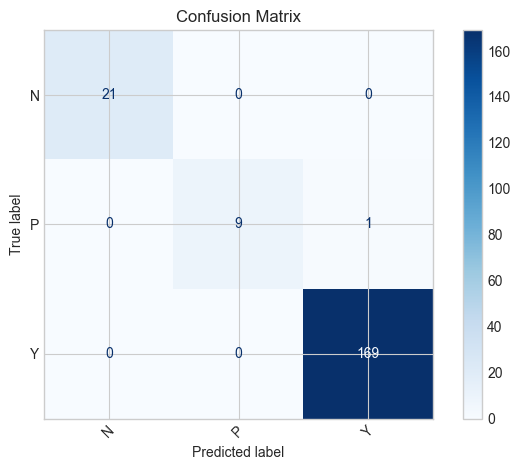

In [4]:
labels = np.unique(y_test)
cm = confusion_matrix(y_test, y_pred, labels=labels)

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels).plot(
    cmap="Blues", xticks_rotation=45
)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

**Interpretation**

- The confusion matrix shows where misclassifications occur across classes.
- Focus on minority-class recall to see whether errors are concentrated in rare classes.


## 4. Error Analysis

Create an error table with model confidence and summarize error rates by class.


In [5]:
# Build an error table with raw feature values
error_df = X_test.copy()
error_df["y_true"] = y_test
error_df["y_pred"] = y_pred
error_df["correct"] = error_df["y_true"] == error_df["y_pred"]

# Add model confidence if available
if hasattr(pipeline, "predict_proba"):
    probas = pipeline.predict_proba(X_test)
    error_df["pred_confidence"] = probas.max(axis=1)
else:
    error_df["pred_confidence"] = np.nan

# Summary: error rate by class
summary = (
    error_df.groupby("y_true")
    .agg(total=("correct", "size"), errors=("correct", lambda s: (~s).sum()))
    .assign(error_rate=lambda d: (d["errors"] / d["total"]).round(3))
    .sort_values("error_rate", ascending=False)
)

display(summary)

# Most confident misclassifications
misclassified = error_df[~error_df["correct"]]

if not misclassified.empty:
    feature_cols = num_cols + cat_cols
    cols = ["y_true", "y_pred", "pred_confidence"] + feature_cols
    display(misclassified.sort_values("pred_confidence", ascending=False).head(10)[cols])
else:
    print("No misclassifications found.")


,total,errors,error_rate
y_true,,,
P,10,1,0.1
N,21,0,0.0
Y,169,0,0.0


,y_true,y_pred,pred_confidence,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,Gender
152,P,Y,0.863333,54,4.0,88,5.7,4.4,2.9,0.6,2.5,1.3,28.0,M


**Interpretation**

Error rates by true class:

- P: total=10, errors=1, error_rate=0.100
- N: total=21, errors=0, error_rate=0.000
- Y: total=169, errors=0, error_rate=0.000

The most confident misclassification has confidence 0.85.


## 5. Feature Importance (Model Insight)

Display the top feature importances from the RandomForest model.


num__HbA1c       0.420546
num__BMI         0.194398
num__AGE         0.162087
num__TG          0.043026
num__Chol        0.041626
num__VLDL        0.032577
num__Urea        0.026059
num__LDL         0.025542
num__Cr          0.023736
num__HDL         0.018920
cat__Gender_F    0.005856
cat__Gender_M    0.005626
dtype: float64

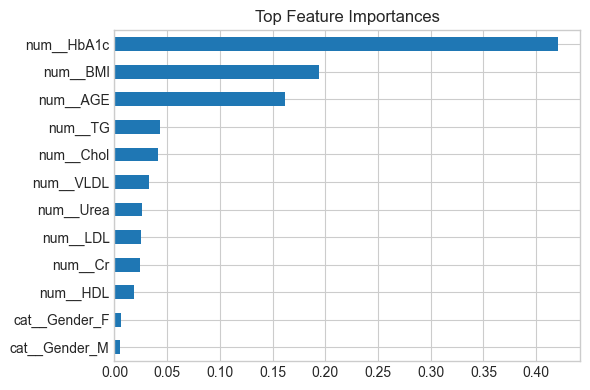

In [6]:
if hasattr(pipeline.named_steps["model"], "feature_importances_"):
    feature_names = pipeline.named_steps["preprocess"].get_feature_names_out()
    fi = pd.Series(
        pipeline.named_steps["model"].feature_importances_,
        index=feature_names,
    ).sort_values(ascending=False)
    display(fi.head(15))

    plt.figure(figsize=(6, 4))
    fi.head(15).iloc[::-1].plot(kind="barh")
    plt.title("Top Feature Importances")
    plt.tight_layout()
    plt.show()


**Interpretation**

- The most important transformed features indicate which inputs drive the model predictions.
- Numeric features are labeled like `num__AGE`, while one-hot categories appear like `cat__Gender_F`.
- Use these names to map importance back to the original features.
